# Setup

In [1]:
from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
display(HTML("<style>div.output_scroll { height: 44em; }</style>"))

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import sys
import h5py
import awkward as ak
import uproot

In [4]:
matplotlib.rcdefaults()  # Reset to defaults first

# Apply ROOT styling without problematic fonts
matplotlib.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 16,
    'axes.titlesize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 12,
    'figure.figsize': (8, 6),
    'axes.linewidth': 1.5,
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'xtick.minor.width': 1.0,
    'ytick.minor.width': 1.0,
    'xtick.major.size': 5,
    'ytick.major.size': 5,
    'xtick.minor.size': 3,
    'ytick.minor.size': 3,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--',
})

print("Matplotlib styling applied successfully")


Matplotlib styling applied successfully


In [5]:
# either add WatChMaL repository directory to PYTHONPATH variable or add it here
sys.path.append('/home/sc4422/scratch/watchmal/')

In [6]:
import watchmal.utils.math as math
from analysis.utils.binning import get_binning
from analysis.utils.plotting import plot_legend
from analysis.regression_multiring import (WatChMaLPositionRegression, WatChMaLDirectionRegression, WatChMaLEnergyRegression, CombinedRegressionRun,
                                 FitQun1ParticleFit, plot_histograms, plot_resolution_profile, plot_bias_profile, tabulate_statistics)
from analysis.read_multiring import FiTQunOutput

Imported analysis code from WatChMaL repository with git version: workshop_2025-149-ga5cffe4-dirty


# Processing h5 data

In [7]:
cds_geo_path = '/home/sc4422/scratch/'

In [8]:
idxs_path_new_geo = cds_geo_path + "/simulation/splits/indep_vert_6M_e_FC.npz"
test_idxs_new_geo  = np.load(idxs_path_new_geo, allow_pickle=True)['test_idxs']

In [9]:
data_path_new_geo = cds_geo_path + "/simulation/h5/wcte_2e-_indep_vert_indep_energy_6M.h5"
h5_file_new_geo = h5py.File(data_path_new_geo, "r")

<class 'numpy.ndarray'>
Shape: (5981987, 2)
Particle 0 range: 0.7750585 1000.77045
Particle 1 range: 0.8506965 1000.77094


Text(0.5, 1.0, 'Combined data (before cuts)')

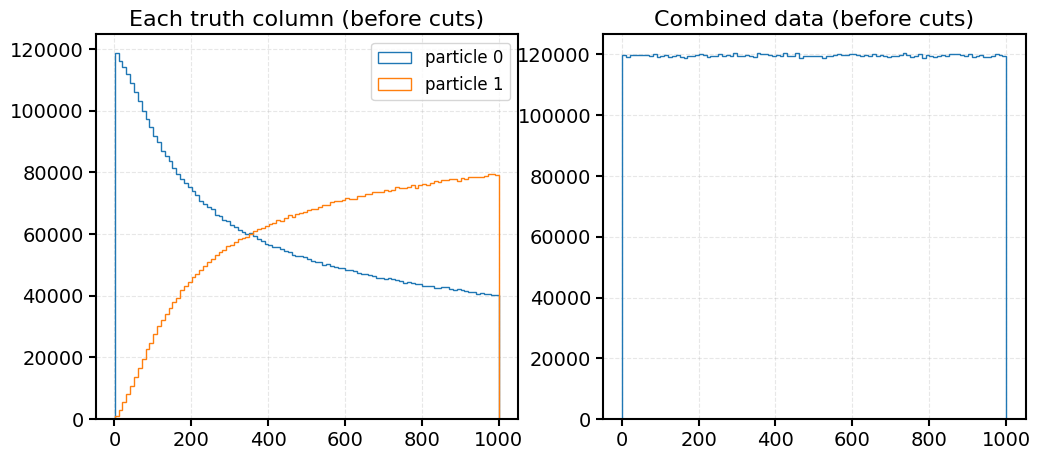

In [10]:
with h5py.File(data_path_new_geo, "r") as f:
    energies = f["energies"][:]

print(type(energies))  # numpy.ndarray

print("Shape:", energies.shape)
print("Particle 0 range:", energies[:, 0].min(), energies[:, 0].max())
print("Particle 1 range:", energies[:, 1].min(), energies[:, 1].max())

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].hist(energies[:, 0], bins=100, histtype="step", label="particle 0")
ax[0].hist(energies[:, 1], bins=100, histtype="step", label="particle 1")
ax[0].legend()
ax[0].set_title("Each truth column (before cuts)")

ax[1].hist(energies.reshape(-1), bins=100, histtype="step")
ax[1].set_title("Combined data (before cuts)")

In [11]:
def get_values(h5file,testidxs):

    h5_angles     = np.array(h5file['angles'])[testidxs].squeeze()
    h5_energies   = np.array(h5file['energies'])[testidxs].squeeze()
    h5_positions  = np.array(h5file['positions'])[testidxs].squeeze()
    h5_labels     = np.array(h5file['labels'])[testidxs].squeeze()
    h5_root_files = np.array(h5file['root_files'])[testidxs].squeeze()
    h5_event_ids  = np.array(h5file['event_ids'])[testidxs].squeeze()
    h5_vetos      = np.array(h5file['veto'])[testidxs].squeeze()
    hitsindex     = np.array(h5file['event_hits_index']).squeeze()
    # h5_charge     = np.array(h5file['hit_charge']).squeeze()
    # charge        = h5_charge[hitsindex[testidxs+1] - h5_charge[hitsindex[testidxs]]]
    # h5_times       = np.array(h5file['hit_time']).squeeze()
    # times         = h5_times[hitsindex[testidxs+1] - h5_times[hitsindex[testidxs]]]
    h5_nhits      = hitsindex[testidxs+1] - hitsindex[testidxs]
    h5_directions = math.direction_from_angles(h5_angles)
    h5_fc = np.array(h5file['fully_contained'])[testidxs].squeeze()

    wcte_radius = 159.63
    wcte_half_height = 141.54

    # some extra values to use in cuts or plotting, calculated from the data read from h5 file
    h5_towall = math.towall(h5_positions, h5_angles, tank_half_height=wcte_half_height, tank_radius=wcte_radius)
    h5_dwall = math.dwall(h5_positions, tank_half_height=wcte_half_height, tank_radius=wcte_radius)
    h5_momentum = math.momentum_from_energy(h5_energies, h5_labels)

    return {
        'angles': h5_angles,
        'energies': h5_energies,
        'positions': h5_positions,
        'labels': h5_labels,
        'root_files': h5_root_files,
        'event_ids': h5_event_ids,
        'vetos': h5_vetos,
        'hitsindex': hitsindex,
        'nhits': h5_nhits,
        'directions': h5_directions,
        'fc': h5_fc,
        'towall':h5_towall,
        'dwall':h5_dwall,
        'momentum':h5_momentum,
        # 'charge': charge,
        # 'times': times
    }

In [12]:
data_new_geo = get_values(h5_file_new_geo, test_idxs_new_geo)

print(data_new_geo['energies'])

[[545.22955  307.6775  ]
 [131.03094   94.948944]
 [111.889534 194.74187 ]
 ...
 [143.12474  674.1025  ]
 [271.06882  352.95352 ]
 [875.71643  111.30386 ]]


In [13]:
### Fixed energy ordering for truth 

def sort_by_energy(data):
    order = np.argsort(data['energies'], axis=1)

    per_particle = {'angles', 'energies', 'positions', 'labels',
                    'directions', 'momentum', 'towall', 'dwall'}

    sorted_dict = dict(data)
    for key in per_particle & data.keys():
        arr = data[key]
        idx = order.reshape(order.shape + (1,) * (arr.ndim - order.ndim))
        sorted_dict[key] = np.take_along_axis(arr, idx, axis=1)
    return sorted_dict
    
data_new_geo = sort_by_energy(data_new_geo)

Shape: (135321, 2)
Shape: (135321, 2, 3)
Particle 0 range: 0.77565455 994.1992
Particle 1 range: 1.0259335 1000.7638


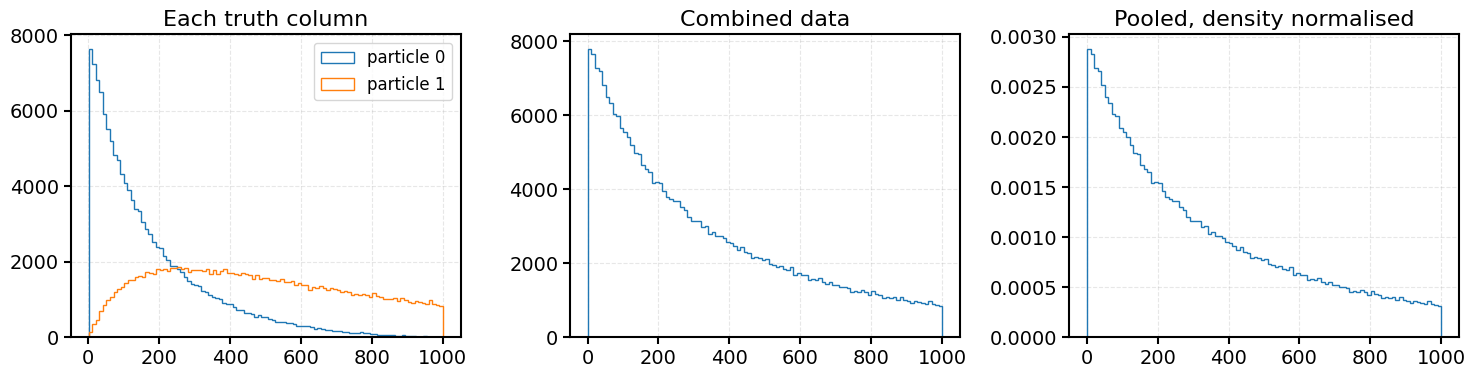

In [14]:
energies = data_new_geo["energies"]
positions = data_new_geo['positions']

print("Shape:", energies.shape)
print("Shape:", positions.shape)
print("Particle 0 range:", energies[:, 0].min(), energies[:, 0].max())
print("Particle 1 range:", energies[:, 1].min(), energies[:, 1].max())

fig, ax = plt.subplots(1, 3, figsize=(15, 4))

ax[0].hist(energies[:, 0], bins=100, histtype="step", label="particle 0")
ax[0].hist(energies[:, 1], bins=100, histtype="step", label="particle 1")
ax[0].legend()
ax[0].set_title("Each truth column")

ax[1].hist(energies.reshape(-1), bins=100, histtype="step")
ax[1].set_title("Combined data")

ax[2].hist(
    energies.reshape(-1),
    bins=100,
    histtype="step",
    density=True,
)
ax[2].set_title("Pooled, density normalised")

plt.tight_layout()
plt.show()

# Processing fitQun data

In [15]:
# def get_cut_start_idxs(all_event_ids: np.ndarray) -> np.ndarray:
#     N = len(all_event_ids)
#     cut_start_idxs: list[int] = [0]
#     CUTOFF = 500
#     for i in range(N - 1):
#         if np.abs(all_event_ids[i + 1] - all_event_ids[i]) >= CUTOFF:
#             cut_start_idxs.append(i+ 1)
#     cut_start_idxs.append(len(all_event_ids)-1)
#     return cut_start_idxs

# def get_missing_per_cut_both(fq_event_ids: np.ndarray, h5_event_ids: np.ndarray, fq_cuts: list[int], h5_cuts: list[int]) -> tuple[list[np.ndarray], np.ndarray]:
#     missing_ids_fq = []
#     missing_inds_fq = []
#     missing_ids_h5 = []    
#     missing_inds_h5 = []
#     n_cuts = len(fq_cuts)
#     assert len(fq_cuts) == len(h5_cuts), "Number of cuts must be the same for both datasets" 
#     for i in range(1, n_cuts):
#         fq_start_idx, fq_end_idx = fq_cuts[i - 1], fq_cuts[i]
#         h5_start_idx, h5_end_idx = h5_cuts[i - 1], h5_cuts[i]

#         fq_ids = fq_event_ids[fq_start_idx:fq_end_idx]
#         h5_ids = h5_event_ids[h5_start_idx:h5_end_idx]

#         assert fq_ids[0] < 100
#         assert fq_ids[-1] > 990

#         missing_both = np.setdiff1d(fq_ids, np.arange(0, 1000))
#         if len(missing_both) > 0:
#             print(missing_both)

#         missing_fq = np.setdiff1d(fq_ids, h5_ids)
#         inds_fq = np.searchsorted(fq_ids, missing_fq)

#         missing_ids_fq.append(missing_fq.tolist())
#         missing_inds_fq.append(fq_start_idx + inds_fq)


#         missing_h5 = np.setdiff1d(h5_ids, fq_ids)
#         inds_h5 = np.searchsorted(h5_ids, missing_h5)

#         missing_ids_h5.append(missing_h5.tolist())
#         missing_inds_h5.append(h5_start_idx + inds_h5)
    
#     return missing_ids_fq, np.concatenate(missing_inds_fq), missing_ids_h5, np.concatenate(missing_inds_h5)

In [16]:
# fitqun_files_full = '/vols/hyperk/WCTE/ML_2025/fitqun_test/fitqun_results/wcsim_wcte_CDS_pgun_ALL_fq.root'
# fq = FiTQunOutput(fitqun_files_full)

In [17]:
# #Checking difference between fitqun and h5 file event id and missing_indices to see if they are the same shape
# fq_event_ids = fq.chain['nevt'] #.compute()
# fq_event_ids =  ak.to_numpy(fq_event_ids) -1
# h5_event_ids = data_new_geo['event_ids']

# fq_cuts = get_cut_start_idxs(fq_event_ids)
# h5_cuts = get_cut_start_idxs(h5_event_ids)
# missing_per_cut_fq, missing_indices_fq, missing_per_cut_h5, missing_indices_h5= get_missing_per_cut_both(fq_event_ids, h5_event_ids, fq_cuts, h5_cuts)

# print('The difference between fitqun and h5 event ids is:', len(fq_event_ids)- len(h5_event_ids))
# print('The number of extra fq indices is:', len(missing_indices_fq))
# print('The number of extra h5 indices is:', len(missing_indices_h5))

In [18]:
# fq_keep_idx = np.delete(np.arange(len(fq_event_ids)), missing_indices_fq)
# h5_keep_idx = np.delete(np.arange(len(data_new_geo['event_ids'])), missing_indices_h5)

# fq_mu_idxs=np.delete(np.arange(0, len(fq_event_ids)),missing_indices_fq)[data_new_geo['labels'][h5_keep_idx]==2]
# fq_e_idxs=np.delete(np.arange(0, len(fq_event_ids)),missing_indices_fq)[data_new_geo['labels'][h5_keep_idx]==1]
# fq_event_ids_new = np.delete(np.arange(0, len(fq_event_ids)), missing_indices_fq)

In [19]:
# h5_electron_flag = fq.electron_flag
# h5_electron_flag = np.delete(ak.to_numpy(h5_electron_flag), missing_indices_fq)
# h5_muon_flag = fq.muon_flag#.compute()
# h5_muon_flag = np.delete(ak.to_numpy(h5_muon_flag), missing_indices_fq)

# fc_cut = data_new_geo['fc'][h5_keep_idx]
# mu_cut = data_new_geo['labels'][h5_keep_idx]==2
# el_cut = data_new_geo['labels'][h5_keep_idx]==1

# reco_cut = (h5_muon_flag == 0) & (h5_electron_flag == 0)

In [20]:
# mu_mu = np.delete(fq.muon_nll, missing_indices_fq)[fc_cut & mu_cut & reco_cut]
# el_mu = np.delete(fq.electron_nll, missing_indices_fq)[fc_cut & mu_cut & reco_cut]

# mu_el = np.delete(fq.muon_nll, missing_indices_fq)[fc_cut & el_cut & reco_cut]
# el_el = np.delete(fq.electron_nll, missing_indices_fq)[fc_cut & el_cut & reco_cut]
# fq_mu_nll = mu_mu - el_mu
# fq_el_nll = mu_el - el_el

# Making cuts and extracting data

In [21]:
font = {'family' : 'DejaVu Sans',
        'weight' : 'normal',
        'size'   : 28}
matplotlib.rc('font', **font)
matplotlib.rcParams['figure.figsize'] = (12, 9)
matplotlib.rcParams["figure.autolayout"] = True

In [22]:
print((data_new_geo['fc'] == True).shape)
print((data_new_geo['towall'] == True).shape)
print((data_new_geo['nhits'] == True).shape)
print((data_new_geo['energies'] == True).shape)


def apply_cuts(data):
    fc_cut = (data['fc'] == True) # truth-based cut to exclude non-fully-contained events
    towall_cut = (data['towall'] > 100).all(axis=1) # if one fails neither work 
    nhits_cut = data['nhits'] > 25
    energies_cut = (data['energies'] > 800).all(axis=1)

    # select the true electron and muon events that pass the cuts
    cuts = ( fc_cut
            & nhits_cut
            & towall_cut
            )
    return cuts

cuts_new_geo = apply_cuts(data_new_geo)


print(cuts_new_geo.shape)

(135321,)
(135321, 2)
(135321,)
(135321, 2)
(135321,)


In [23]:
e_idxs_new_geo = data_new_geo['labels']==1
mu_idxs_new_geo = data_new_geo['labels']==2

In [24]:
print(data_new_geo['labels'].shape)
print((data_new_geo['labels'] == 1)[:3,:])

def get_particle_quantities(data, ring, particle_type, cuts=None):
    """
    Extracts quantities for a given particle type from the data dictionary and
    returns a tuple in the order expected by the notebook unpacking.

    Returns: (labels, momentum, positions, directions, angles,
              dwall, towall, cuts_selected, indices)
    """
    if ring is not None:
        particle_mask = data['labels'][:,ring] == particle_type

        labels = data['labels'][:,ring][particle_mask]
        momentum = data['momentum'][:,ring][particle_mask]
        positions = data['positions'][:,ring][particle_mask]
        directions = data['directions'][:,ring][particle_mask]
        angles = data['angles'][:,ring][particle_mask]
        dwall = data['dwall'][:,ring][particle_mask]
        towall = data['towall'][:,ring][particle_mask]
        cuts_selected = cuts[particle_mask] if cuts is not None else None
        indices = cuts[particle_mask]
    else:
#         particle_mask = data['labels'][:,0] == particle_type # for now

        labels = data['labels']
        momentum = data['momentum']
        positions = data['positions']
        directions = data['directions']
        angles = data['angles']
        dwall = data['dwall']
        towall = data['towall']
        cuts_selected = cuts if cuts is not None else None
        indices = cuts

    return (labels, momentum, positions, directions, angles,
            dwall, towall, cuts_selected, indices)

(135321, 2)
[[ True  True]
 [ True  True]
 [ True  True]]


In [25]:
e_labels_0, e_mom_0, e_pos_0, e_dir_0, e_ang_0, e_dwall_0, e_towall_0, e_cuts_0, e_idxs_0 = get_particle_quantities(data_new_geo, ring=0, particle_type=1, cuts=cuts_new_geo)
e_labels_1, e_mom_1, e_pos_1, e_dir_1, e_ang_1, e_dwall_1, e_towall_1, e_cuts_1, e_idxs_1 = get_particle_quantities(data_new_geo,  ring=1, particle_type=1, cuts=cuts_new_geo)

cut_1 = e_mom_1[e_idxs_1]
print(cut_1.shape)
print(e_mom_1.shape)
# cut_0 = e_mom_0[e_idxs_0]

# cut = np.concatenate((cut_0, cut_1))

# print("Shape:", cut.shape)
# print("Particle  range:", cut[:].min(), cut[:].max())
# # print("Particle 1 range:", energies[:, 1].min(), energies[:, 1].max())

# fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# ax[0].hist(cut_0[:], bins=100, histtype="step", label="particle 0")
# ax[0].hist(cut_1[:], bins=100, histtype="step", label="particle 1")
# ax[0].legend()
# ax[0].set_title("Truth columns (after cuts)")

# ax[1].hist(cut, bins=100, histtype="step")
# ax[1].set_title("Combined data (after cuts)")

# plt.show()

# mu_labels_0, mu_mom_0, mu_pos_0, mu_dir_0, mu_ang_0, mu_dwall_0, mu_towall_0, mu_cuts_0, mu_idxs_0 = get_particle_quantities(data_new_geo,  ring=0, particle_type=2, cuts=cuts_new_geo)
# mu_labels_1, mu_mom_1, mu_pos_1, mu_dir_1, mu_ang_1, mu_dwall_1, mu_towall_1, mu_cuts_1, mu_idxs_1 = get_particle_quantities(data_new_geo, ring=1,particle_type=2,  cuts=cuts_new_geo)

(84493,)
(135321,)


In [26]:
e_labels, e_mom, e_pos, e_dir, e_ang, e_dwall, e_towall, e_cuts, e_idxs = get_particle_quantities(data_new_geo,  ring=None, particle_type=1, cuts=cuts_new_geo)

cut = e_mom[e_cuts]
print(cut.shape)
print(e_mom.shape)

print(e_pos.shape)

(84493, 2)
(135321, 2)
(135321, 2, 3)


In [27]:
e_idxs_new_geo_0 = data_new_geo['labels'][:, 0] == 1
e_idxs_new_geo_1 = data_new_geo['labels'][:, 1] == 1

mu_idxs_new_geo_0 = data_new_geo['labels'][:, 0] == 2
mu_idxs_new_geo_1 = data_new_geo['labels'][:, 1] == 2

resnet_args = {'linestyle':"-"}
electron_args_new_geo_0 = {'indices':test_idxs_new_geo[e_idxs_new_geo_0], 'selection':e_cuts_0}
electron_args_new_geo_1 = {'indices':test_idxs_new_geo[e_idxs_new_geo_1], 'selection':e_cuts_1}

print(electron_args_new_geo_0)
print(electron_args_new_geo_1) # these are identical bc the test indices, cuts and e indices are identical but will need to use separate if using different particles in the future

print(np.all(electron_args_new_geo_0['selection'] == electron_args_new_geo_1['selection']))


{'indices': array([      1,      10,      11, ..., 3983981, 3983986, 3983988]), 'selection': array([ True, False, False, ..., False,  True,  True])}
{'indices': array([      1,      10,      11, ..., 3983981, 3983986, 3983988]), 'selection': array([ True, False, False, ..., False,  True,  True])}
True


# Loading ResNet results

In [28]:
outdir_reg = "/home/sc4422/scratch/output/regression/multiring/"

In [29]:
resnet_trial_1 = 'electrons/2026-07-07/16-17-04/'
hiertrans_trial_1 = 'gnn/electrons/2026-07-07/17-01-43/'
nonhiergat_trial_1 = 'gnn/electrons/2026-07-07/17-13-58/'
# ## ring 0
# e_position_0 = [
#     WatChMaLPositionRegression(outdir_reg + resnet_trial_1, 0, "ResNet 50 Position", e_pos_0, e_dir_0, **electron_args_new_geo_0, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + hiertrans_trial_1, 0, "HierTrans Position", e_pos_0, e_dir_0, **electron_args_new_geo_0, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nonhiergat_trial_1, 0, "NonHierGAT Position", e_pos_0, e_dir_0, **electron_args_new_geo_0, **resnet_args),
# ]
# e_direction_0 = [
#     WatChMaLDirectionRegression(outdir_reg + resnet_trial_1, 0, "ResNet 50 Direction", e_dir_0, **electron_args_new_geo_0, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + hiertrans_trial_1, 0, "HierTrans Direction", e_dir_0, **electron_args_new_geo_0, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + nonhiergat_trial_1, 0, "NonHierGAT Direction", e_dir_0, **electron_args_new_geo_0, **resnet_args),
# ]
# e_energy_0 = [
#     WatChMaLEnergyRegression(outdir_reg + resnet_trial_1, 0, "ResNet 50 Energy", e_mom_0, 1, **electron_args_new_geo_0, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + hiertrans_trial_1, 0, "HierTrans Energy", e_mom_0, 1, **electron_args_new_geo_0, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + nonhiergat_trial_1, 0, "NonHierGAT Energy", e_mom_0, 1, **electron_args_new_geo_0, **resnet_args),
# ]

# ## ring 1
# e_position_1 = [
#     WatChMaLPositionRegression(outdir_reg + resnet_trial_1, 1, "ResNet 50 Position", e_pos_1, e_dir_1, **electron_args_new_geo_1, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + hiertrans_trial_1, 1, "HierTrans Position", e_pos_1, e_dir_1, **electron_args_new_geo_1, **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nonhiergat_trial_1, 1, "NonHierGAT Position", e_pos_1, e_dir_1, **electron_args_new_geo_1, **resnet_args),
# ]
# e_direction_1 = [
#     WatChMaLDirectionRegression(outdir_reg + resnet_trial_1, 1, "ResNet 50 Direction", e_dir_1, **electron_args_new_geo_1, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + hiertrans_trial_1, 1, "HierTrans Direction", e_dir_1, **electron_args_new_geo_1, **resnet_args),
#     WatChMaLDirectionRegression(outdir_reg + nonhiergat_trial_1, 1, "NonHierGAT Direction", e_dir_1, **electron_args_new_geo_1, **resnet_args),
# ]
# e_energy_1 = [
#     WatChMaLEnergyRegression(outdir_reg + resnet_trial_1, 1, "ResNet 50 Energy", e_mom_1, 1, **electron_args_new_geo_1, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + hiertrans_trial_1, 1, "HierTrans Energy", e_mom_1, 1, **electron_args_new_geo_1, **resnet_args),
#     WatChMaLEnergyRegression(outdir_reg + nonhiergat_trial_1, 1, "NonHierGAT Energy", e_mom_1, 1, **electron_args_new_geo_1, **resnet_args),
# ]

In [30]:

## find the comparison to energy ordering (will have finsihed on last monday)


##hungarian
ht_mse = 'gnn/electrons/2026-07-14/10-50-33/'
nhg_mse ='gnn/electrons/2026-07-14/10-50-34/'
res_mse = 'electrons/2026-07-14/10-50-35/'
ht_mse_scale100 = 'gnn/electrons/2026-07-14/10-50-35/'
nhg_mse_scale100 = 'gnn/electrons/2026-07-14/10-50-36/'
ht_huber = 'gnn/electrons/2026-07-14/20-36-45/'
nhg_huber = 'gnn/electrons/2026-07-14/20-36-41/'
resnet_huber = 'electrons/2026-07-14/20-36-45/'
ht_sep_head = 'gnn/electrons/2026-07-16/16-58-45/'
nhg_sep_head = 'gnn/electrons/2026-07-16/16-55-40/'
# resnet_sep_head = 'electrons/2026-07-16/17-05-12/' ## wrong
ht_layer_1 = 'gnn/electrons/2026-07-17/04-36-11/'
nhg_layer_1 = 'gnn/electrons/2026-07-17/04-36-54/'
resnet_layer_1 = 'electrons/2026-07-17/04-32-56/'
ht_layer_2 = 'gnn/electrons/2026-07-17/03-27-51/'
nhg_layer_2 = 'gnn/electrons/2026-07-17/03-27-46/'
resnet_layer_2 = 'electrons/2026-07-17/04-21-51/'
ht_layer_4 = 'gnn/electrons/2026-07-17/03-29-47/'
nhg_layer_4 = 'gnn/electrons/2026-07-17/03-31-51/'
resnet_layer_4 = 'electrons/2026-07-17/04-21-47/'

# e_position_0 = [
#     WatChMaLPositionRegression(outdir_reg + ht_mse, 0, "HT Ring 0 MSE", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_mse, 0, "NHG Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + res_mse, 0, "ResNet Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + ht_mse_scale100, 0, "HT Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, **resnet_args, match_truth=data_new_geo['positions']),
# #     WatChMaLPositionRegression(outdir_reg + nhg_mse_scale100, 0, "NHG Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, **resnet_args, match_truth=data_new_geo['positions']),
#     WatChMaLPositionRegression(outdir_reg + ht_huber, 0, "HT Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_huber, 0, "NHG Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + resnet_huber, 0, "ResNet Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + ht_sep_head, 0, "HT Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + nhg_sep_head, 0, "NHG Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + resnet_sep_head, 0, "ResNet Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),  ## wrong
# #     WatChMaLPositionRegression(outdir_reg + ht_layer_1, 0, "HT Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + nhg_layer_1, 0, "NHG Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + resnet_layer_1, 0, "ResNet Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + ht_layer_2, 0, "HT Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + nhg_layer_2, 0, "NHG Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + resnet_layer_2, 0, "ResNet Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + ht_layer_4, 0, "HT Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + nhg_layer_4, 0, "NHG Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + resnet_layer_4, 0, "ResNet Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
# ]
# e_position_1 = [
#     WatChMaLPositionRegression(outdir_reg + ht_mse, 1, "HT Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_mse, 1, "NHG Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + res_mse, 1, "ResNet Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + ht_mse_scale100, 1, "HT Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, **resnet_args, match_truth=data_new_geo['positions']),
# #     WatChMaLPositionRegression(outdir_reg + nhg_mse_scale100, 1, "NHG Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, **resnet_args, match_truth=data_new_geo['positions']),
#     WatChMaLPositionRegression(outdir_reg + ht_huber, 1, "HT Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_huber, 1, "NHG Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + resnet_huber, 1, "ResNet Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + ht_sep_head, 1, "HT Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + nhg_sep_head, 1, "NHG Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + resnet_sep_head, 1, "ResNet Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),  ## wrong
# #     WatChMaLPositionRegression(outdir_reg + ht_layer_1, 1, "HT Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + nhg_layer_1, 1, "NHG Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + resnet_layer_1, 1, "ResNet Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + ht_layer_2, 1, "HT Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + nhg_layer_2, 1, "NHG Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + resnet_layer_2, 1, "ResNet Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + ht_layer_4, 1, "HT Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + nhg_layer_4, 1, "NHG Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + resnet_layer_4, 1, "ResNet Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
# ]


# e_position_0 = [
# #     WatChMaLPositionRegression(outdir_reg + ht_mse, 0, "HT Ring 0 MSE", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + ht_huber, 0, "HT", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + ht_sep_head, 0, "HT Sep head", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
# # #     WatChMaLPositionRegression(outdir_reg + nhg_mse, 0, "NHG Ring 0 MSE", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + nhg_huber, 0, "NHG Huber", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + nhg_sep_head, 0, "NHG Sep head", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + res_mse, 0, "ResNet Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + ht_mse_scale100, 0, "HT Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, **resnet_args, match_truth=data_new_geo['positions']),
# #     WatChMaLPositionRegression(outdir_reg + nhg_mse_scale100, 0, "NHG Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, **resnet_args, match_truth=data_new_geo['positions']),
# #     WatChMaLPositionRegression(outdir_reg + resnet_huber, 0, "ResNet Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + ht_sep_head, 0, "HT Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + nhg_sep_head, 0, "NHG Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + resnet_sep_head, 0, "ResNet Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),  ## wrong
#     WatChMaLPositionRegression(outdir_reg + ht_layer_1, 0, "HT Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_layer_1, 0, "NHG Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + resnet_layer_1, 0, "ResNet Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + ht_layer_2, 0, "HT Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_layer_2, 0, "NHG Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + resnet_layer_2, 0, "ResNet Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + ht_layer_4, 0, "HT Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_layer_4, 0, "NHG Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + resnet_layer_4, 0, "ResNet Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
# ]
# e_position_1 = [
# #     WatChMaLPositionRegression(outdir_reg + ht_mse, 1, "HT Ring 1 MSE", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + nhg_mse, 1, "NHG Ring 1 MSE", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + ht_huber, 1, "HT", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + ht_sep_head, 1, "HT Sep head", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + nhg_huber, 1, "NHG", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + nhg_sep_head, 1, "NHG Sep head", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + res_mse, 1, "ResNet Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + ht_mse_scale100, 1, "HT Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, **resnet_args, match_truth=data_new_geo['positions']),
# #     WatChMaLPositionRegression(outdir_reg + nhg_mse_scale100, 1, "NHG Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, **resnet_args, match_truth=data_new_geo['positions']),
# #     WatChMaLPositionRegression(outdir_reg + resnet_huber, 1, "ResNet Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + resnet_sep_head, 1, "ResNet Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),  ## wrong
#     WatChMaLPositionRegression(outdir_reg + ht_layer_1, 1, "HT Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_layer_1, 1, "NHG Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + resnet_layer_1, 1, "ResNet Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + ht_layer_2, 1, "HT Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_layer_2, 1, "NHG Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + resnet_layer_2, 1, "ResNet Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + ht_layer_4, 1, "HT Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_layer_4, 1, "NHG Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + resnet_layer_4, 1, "ResNet Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
# ]

## query pos first test

nhg_querypos_noscale_3l = 'gnn/electrons/2026-07-17/16-57-08/'
ht_querypos_noscale_3l = 'gnn/electrons/2026-07-17/16-57-38/'
# nhg 2 l gnn/electrons/2026-07-17/16-58-07/


## query pos with scaling

ht_noquerpos_3l = 'gnn/electrons/2026-07-18/03-35-40/'
ht_querpos_3l = 'gnn/electrons/2026-07-18/07-48-58/' 
nhg_querpos_3l = 'gnn/electrons/2026-07-18/07-59-42/'
ht_querpos_3l_0_001 = 'gnn/electrons/2026-07-18/09-03-11/'

## aux loss with query pos

nhg_auxloss = 'gnn/electrons/2026-07-21/18-49-08/'
ht_auxloss = 'gnn/electrons/2026-07-21/19-28-12/'

# e_position_0 = [
#     WatChMaLPositionRegression(outdir_reg + ht_huber, 0, "HT Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_huber, 0, "NHG Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
#     # query pos first test (no scaling)
# #     WatChMaLPositionRegression(outdir_reg + nhg_querypos_noscale_3l, 0, "NHG QueryPos NoScale 3L Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + ht_querypos_noscale_3l_lr_0_001, 0, "HT QueryPos NoScale 3L lr=0.001 Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + ht_querypos_noscale_3l, 0, "HT QueryPos NoScale 3L Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
#     # query pos with scaling
#     WatChMaLPositionRegression(outdir_reg + ht_noquerpos_3l, 0, "HT NoQueryPos 3L Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + ht_querpos_3l, 0, "HT QueryPos 3L Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_querpos_3l, 0, "NHG QueryPos 3L Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + ht_querpos_3l_0_001, 0, "HT QueryPos 3L lr=0.001 Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + ht_auxloss, 0, "ht_auxloss Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_auxloss, 0, "nhg_auxloss Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
# ]

# e_position_1 = [
#     WatChMaLPositionRegression(outdir_reg + ht_huber, 1, "HT Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_huber, 1, "NHG Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
#     # query pos first test (no scaling)
# #     WatChMaLPositionRegression(outdir_reg + nhg_querypos_noscale_3l, 1, "NHG QueryPos NoScale 3L Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + ht_querypos_noscale_3l_lr_0_001, 1, "HT QueryPos NoScale 3L lr=0.001 Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + ht_querypos_noscale_3l, 1, "HT QueryPos NoScale 3L Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
#     # query pos with scaling
#     WatChMaLPositionRegression(outdir_reg + ht_noquerpos_3l, 1, "HT NoQueryPos 3L Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + ht_querpos_3l, 1, "HT QueryPos 3L Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_querpos_3l, 1, "NHG QueryPos 3L Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + ht_querpos_3l_0_001, 1, "HT QueryPos 3L lr=0.001 Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + ht_auxloss, 1, "ht_auxloss", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_auxloss, 1, "nhg_auxloss Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
# ]

# e_position_0 = [
#     WatChMaLPositionRegression(outdir_reg + ht_huber, 0, "HT", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + ht_querpos_3l, 0, "HT QueryPos (Scaled)", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_huber, 0, "NHG Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_querpos_3l, 0, "NHG QueryPos (Scaled)", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
#     # query pos first test (no scaling)
#     # query pos with scaling
# #     WatChMaLPositionRegression(outdir_reg + ht_noquerpos_3l, 0, "HT NoQueryPos 3L Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + ht_querpos_3l, 0, "HT QueryPos 3L Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + nhg_querpos_3l, 0, "NHG QueryPos 3L Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + ht_querpos_3l_0_001, 0, "HT QueryPos 3L lr=0.001 Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
# ]

# e_position_1 = [
#     WatChMaLPositionRegression(outdir_reg + ht_huber, 1, "HT", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + ht_querpos_3l, 1, "HT QueryPos (Scaled)", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_huber, 1, "NHG", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_querpos_3l, 1, "NHG QueryPos (Scaled)", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
#     # query pos first test (no scaling)
#     # query pos with scaling
# #     WatChMaLPositionRegression(outdir_reg + ht_noquerpos_3l, 1, "HT NoQueryPos 3L Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + ht_querpos_3l, 1, "HT QueryPos 3L Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + nhg_querpos_3l, 1, "NHG QueryPos 3L Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
# #     WatChMaLPositionRegression(outdir_reg + ht_querpos_3l_0_001, 1, "HT QueryPos 3L lr=0.001 Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
# ]



In [31]:
# slot prediction

e_position_slot_0 = [
    WatChMaLPositionRegression(outdir_reg + ht_huber, 0, "HT Ring 0", e_pos, e_dir, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args, anchor = 'pred'),
#     WatChMaLPositionRegression(outdir_reg + nhg_huber, 0, "NHG Ring 0", e_pos, e_dir, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args, anchor = 'pred'),
#     WatChMaLPositionRegression(outdir_reg + ht_auxloss, 0, "ht_auxloss Ring 0", e_pos, e_dir, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args, anchor = 'pred'),
#     WatChMaLPositionRegression(outdir_reg + nhg_auxloss, 0, "nhg_auxloss Ring 0", e_pos, e_dir, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args, anchor = 'pred'),
]

e_position_slot_1 = [
    WatChMaLPositionRegression(outdir_reg + ht_huber, 1, "HT Ring 1", e_pos, e_dir, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args, anchor = 'pred'),
#     WatChMaLPositionRegression(outdir_reg + nhg_huber, 1, "NHG Ring 1", e_pos, e_dir, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args, anchor = 'pred'),
#     WatChMaLPositionRegression(outdir_reg + ht_auxloss, 1, "ht_auxloss", e_pos, e_dir, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args, anchor = 'pred'),
#     WatChMaLPositionRegression(outdir_reg + nhg_auxloss, 1, "nhg_auxloss Ring 1", e_pos, e_dir, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args, anchor = 'pred'),
]

### For comparison between runs

# truth energy prediction

e_position_truth_0 = [
    WatChMaLPositionRegression(outdir_reg + ht_huber, 0, "HT Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_huber, 0, "NHG Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + ht_auxloss, 0, "ht_auxloss Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_auxloss, 0, "nhg_auxloss Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
]

e_position_truth_1 = [
    WatChMaLPositionRegression(outdir_reg + ht_huber, 1, "HT Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_huber, 1, "NHG Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + ht_auxloss, 1, "ht_auxloss", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_auxloss, 1, "nhg_auxloss Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
]

# mean prediction

e_position_mean = [
    WatChMaLPositionRegression(outdir_reg + ht_huber, None, "HT", e_pos, e_dir, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_huber, None, "NHG", e_pos, e_dir, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + ht_auxloss, None, "ht_auxloss", e_pos, e_dir, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_auxloss, None, "nhg_auxloss", e_pos, e_dir, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
]


In [75]:
nhg_auxloss_qpos = 'gnn/electrons/2026-07-21/18-49-08/'
ht_auxloss_qpos = 'gnn/electrons/2026-07-21/19-28-12/'

ht_aux_loss = 'gnn/electrons/2026-07-22/04-28-37/'
nhg_aux_loss = 'gnn/electrons/2026-07-22/04-31-20/'

# # slot prediction

e_position_slot_0 = [
#     WatChMaLPositionRegression(outdir_reg + ht_huber, 0, "HT Ring 0", e_pos, e_dir, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args, anchor = 'pred'),
#     WatChMaLPositionRegression(outdir_reg + ht_aux_loss, 0, "ht_auxloss Ring 0", e_pos, e_dir, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args, anchor = 'pred'),
#     WatChMaLPositionRegression(outdir_reg + ht_querpos_3l, 0, "ht_querpos_3l Ring 0", e_pos, e_dir, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args, anchor = 'pred'),
    WatChMaLPositionRegression(outdir_reg + ht_auxloss_qpos, 0, "ht_auxloss_qpos Ring 0", e_pos, e_dir, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args, anchor = 'pred'),
]

e_position_slot_1 = [
#     WatChMaLPositionRegression(outdir_reg + ht_huber, 1, "HT Ring 1", e_pos, e_dir, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args, anchor = 'pred'),
#     WatChMaLPositionRegression(outdir_reg + ht_aux_loss, 1, "ht_aux_loss Ring 1", e_pos, e_dir, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args, anchor = 'pred'),
#     WatChMaLPositionRegression(outdir_reg + ht_querpos_3l, 1, "ht_querpos_3l", e_pos, e_dir, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args, anchor = 'pred'),
    WatChMaLPositionRegression(outdir_reg + ht_auxloss_qpos, 1, "ht_auxloss_qpos Ring 1", e_pos, e_dir, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args, anchor = 'pred'),
]

# ### For comparison between runs

# # truth energy prediction

e_position_truth_0 = [
#     WatChMaLPositionRegression(outdir_reg + ht_huber, 0, "HT Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + ht_aux_loss, 0, "ht_aux_loss Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + ht_querpos_3l, 0, "ht_querpos_3l Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
    WatChMaLPositionRegression(outdir_reg + ht_auxloss_qpos, 0, "ht_auxloss_qpos Ring 0", e_pos_0, e_dir_0, **electron_args_new_geo_0, match_truth=data_new_geo['positions'], **resnet_args),
]

e_position_truth_1 = [
#     WatChMaLPositionRegression(outdir_reg + ht_huber, 1, "HT Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + ht_aux_loss, 1, "ht_aux_loss Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + ht_querpos_3l, 1, "ht_querpos_3l", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
    WatChMaLPositionRegression(outdir_reg + ht_auxloss_qpos, 1, "ht_auxloss_qpos Ring 1", e_pos_1, e_dir_1, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
]

# mean prediction
##HT
e_position_mean = [
    WatChMaLPositionRegression(outdir_reg + ht_huber, None, "HT", e_pos, e_dir, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
    WatChMaLPositionRegression(outdir_reg + ht_aux_loss, None, "ht_aux_loss", e_pos, e_dir, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
    WatChMaLPositionRegression(outdir_reg + ht_querpos_3l, None, "ht_querpos_3l", e_pos, e_dir, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
    WatChMaLPositionRegression(outdir_reg + ht_auxloss_qpos, None, "ht_auxloss_qpos", e_pos, e_dir, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
]

## NHG

# e_position_mean = [
#     WatChMaLPositionRegression(outdir_reg + nhg_huber, None, "nhg", e_pos, e_dir, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_aux_loss, None, "nhg_aux_loss", e_pos, e_dir, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_querpos_3l, None, "nhg_querpos_3l", e_pos, e_dir, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
#     WatChMaLPositionRegression(outdir_reg + nhg_auxloss_qpos, None, "nhg_auxloss_qpos", e_pos, e_dir, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
# ]


# Plot training progression

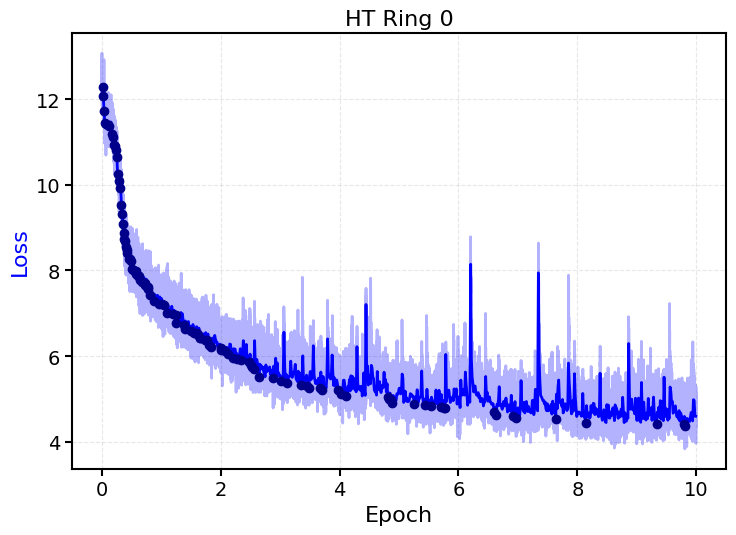

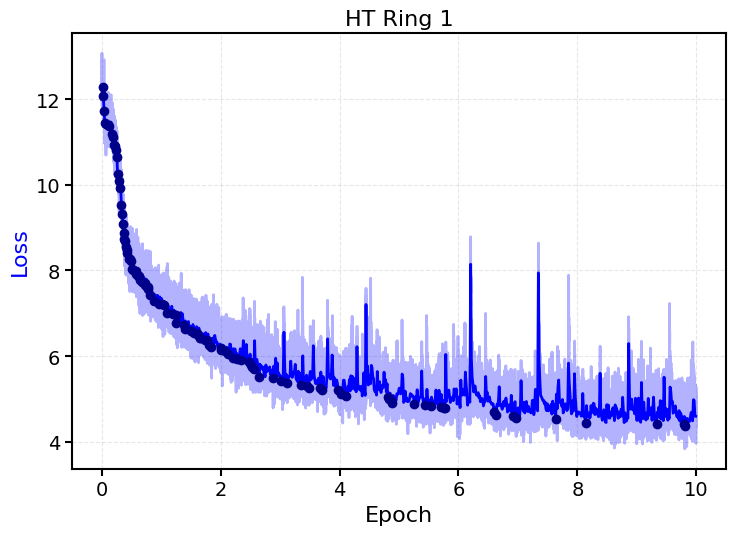

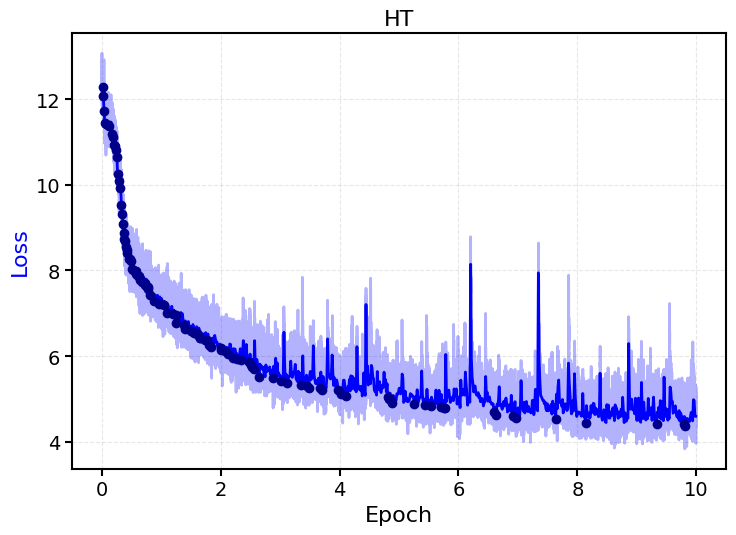

In [32]:
# for r in resnet_muon_energy:
#     fig, ax1 = r.plot_training_progression(fig_size=(8,6), title=r.run_label, plot_best=True)
#     # fig, ax1 = r.plot_validation_progression(legend=None, fig_size=(8,6))
#     ax1.set_yscale('log')
#     # ax1.set_ylim(0.1, 100)
#     # ax1.set_xlim(10,)
# for r in resnet_muon_direction:
#     fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)
# # for r in resnet_muon_energy:
# #     fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)
# for r in resnet_muon_position:
#     fig, ax1 = r.plot_training_progression(fig_size=(8,6), title=r.run_label, plot_best=True)
#     # fig, ax1 = r.plot_validation_progression(legend=None, fig_size=(8,6))
#     ax1.set_yscale('log')
    
for r in e_position_slot_0:
    fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)

for r in e_position_truth_1:
    fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)

for r in e_position_mean:
    fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)
# for r in resnet_e_direction:
#     fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)
# for r in resnet_e_energy:
#     fig, ax1 = r.plot_training_progression(legend=None, fig_size=(8,6), title=r.run_label)

# Energy and position statistics

In [40]:
position_stats = ['x_residuals', 'y_residuals', 'z_residuals', 'position_3d_errors', 'position_transverse_errors', 'position_longitudinal_errors', 'position_longitudinal_errors']
position_stat_labels = ["x position resolution [cm]", "y position resolution [cm]", "z position resolution [cm]", "3D position resolution [cm]", "Transverse position resolution [cm]", "Longitudinal position resolution [cm]", "Longitudinal position mean bias [cm]"]
position_stat_types = ['resolution', 'resolution', 'resolution', 'resolution', 'resolution', 'resolution', 'mean']
# tabulate_statistics(resnet_muon_position, position_stats, position_stat_labels, position_stat_types) 

In [56]:
tabulate_statistics(e_position_slot_0, position_stats, position_stat_labels, position_stat_types)

,HT Ring 0,ht_auxloss Ring 0,ht_querpos_3l Ring 0,ht_auxloss_qpos Ring 0
x position resolution [cm],21.15,20.43,20.06,18.79
y position resolution [cm],20.44,20.70,19.74,17.72
z position resolution [cm],20.64,20.64,19.54,18.48
3D position resolution [cm],40.51,40.66,38.91,35.93
Transverse position resolution [cm],32.50,31.56,30.26,28.07
Longitudinal position resolution [cm],19.86,20.86,19.93,18.35
Longitudinal position mean bias [cm],5.34,10.08,9.63,9.75


In [57]:
tabulate_statistics(e_position_slot_1, position_stats, position_stat_labels, position_stat_types)

,HT Ring 1,ht_aux_loss Ring 1,ht_querpos_3l,ht_auxloss_qpos Ring 1
x position resolution [cm],25.77,20.99,22.38,17.73
y position resolution [cm],24.00,20.30,21.59,17.01
z position resolution [cm],25.95,20.99,22.31,17.56
3D position resolution [cm],50.90,40.98,43.97,34.24
Transverse position resolution [cm],37.71,31.48,33.28,27.10
Longitudinal position resolution [cm],27.34,21.40,23.25,17.14
Longitudinal position mean bias [cm],15.68,10.48,13.33,7.69


In [43]:
tabulate_statistics(e_position_truth_0, position_stats, position_stat_labels, position_stat_types)

,HT Ring 0
x position resolution [cm],30.61
y position resolution [cm],29.05
z position resolution [cm],30.19
3D position resolution [cm],61.50
Transverse position resolution [cm],45.64
Longitudinal position resolution [cm],32.04
Longitudinal position mean bias [cm],15.49


In [44]:
tabulate_statistics(e_position_truth_1, position_stats, position_stat_labels, position_stat_types)

,HT Ring 1
x position resolution [cm],18.18
y position resolution [cm],17.15
z position resolution [cm],18.01
3D position resolution [cm],34.18
Transverse position resolution [cm],27.56
Longitudinal position resolution [cm],17.06
Longitudinal position mean bias [cm],5.54


In [51]:
tabulate_statistics(e_position_mean, position_stats, position_stat_labels, position_stat_types)

,HT,ht_aux_loss,ht_querpos_3l,ht_auxloss_qpos
x position resolution [cm],23.32,20.72,21.21,18.24
y position resolution [cm],22.10,20.50,20.65,17.35
z position resolution [cm],23.16,20.82,20.89,18.01
3D position resolution [cm],45.41,40.83,41.36,35.10
Transverse position resolution [cm],34.98,31.52,31.71,27.60
Longitudinal position resolution [cm],23.24,21.15,21.52,17.75
Longitudinal position mean bias [cm],10.51,10.28,11.48,8.72


In [39]:
# energy_stats = ["momentum_fractional_errors", "momentum_residuals"]
# energy_stat_labels = ["Momentum fractional error resolution", "Momentum residual resolution"]
# energy_stat_types = ['resolution', 'resolution']

energy_percentage_errors = lambda r: r.energy_fractional_errors*100
momentum_percentage_errors = lambda r: r.momentum_fractional_errors*100

energy_stats = [energy_percentage_errors, momentum_percentage_errors,energy_percentage_errors, momentum_percentage_errors]
# energy_stats = ["energy_fractional_errors", "energy_residuals", 'momentum_residuals', 'momentum_fractional_errors']
energy_stat_labels = ['Energy percentage errors', 'Momentum percentage errors','Energy percentage error (bias)', 'Momentum percentage errors (bias)']
energy_stat_types = ['resolution', 'resolution','mean','mean']

tabulate_statistics(resnet_muon_energy, energy_stats, energy_stat_labels, energy_stat_types)


NameError: name 'resnet_muon_energy' is not defined

In [ ]:
E = np.asarray(data_new_geo['energies'])
print("slot0 higher energy fraction:", (E[:, 0] > E[:, 1]).mean())

pred_sep = np.linalg.norm(raw[:, 0] - raw[:, 1], axis=-1)
true_sep = np.linalg.norm(truth[:, 0] - truth[:, 1], axis=-1)
print("median pred sep:", np.median(pred_sep), "median true sep:", np.median(true_sep))

matched = run.get_outputs("predicted_positions")
print("68th pct:", np.quantile(np.linalg.norm(matched - np.asarray(e_pos_1), axis=-1), 0.68))

print("identical slots:", (raw[:, 0] == raw[:, 1]).all(axis=-1).mean())

In [ ]:
import inspect
import analysis.regression_multiring as reg   # or whatever your import path is
import analysis.read_multiring as rm

print(reg.__file__)   # is this the file you actually edited?
print(inspect.signature(reg.WatChMaLPositionRegression.__init__))   # should show match_truth, anchor
print(inspect.signature(rm.WatChMaLOutput.get_outputs))             # should show apply_swap, select_ring

In [ ]:
run = WatChMaLPositionRegression(outdir_reg + ht_mse, 1, "HT Ring 1", e_pos_1, e_dir_1,
                                 **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args)

print("swap fraction:", run.swap.mean())

raw = run.get_outputs("predicted_positions", apply_swap=False, select_ring=False)
truth = np.asarray(data_new_geo['positions'])
print("preds:", raw.shape, "truth:", truth.shape)          # both (N, 2, 3), same N
print("pred range:", raw.min(), raw.max())
print("truth range:", truth.min(), truth.max())            # should be same units/scale!
print("e_pos_1 matches truth[:,1]:", np.allclose(np.asarray(e_pos_1), truth[:, 1]))

In [ ]:
tabulate_statistics(resnet_e_energy, energy_stats, energy_stat_labels, energy_stat_types)

In [ ]:
import copy

resnet_e_energy_clipped = copy.deepcopy(resnet_e_energy)

for r in resnet_e_energy_clipped:
    pred = np.asarray(r.predictions).squeeze()
    physical_mask = pred >= 0.511
    existing = np.zeros(len(pred), dtype=bool)
    existing[r.selection] = True
    r.selection = existing & physical_mask

tabulate_statistics(resnet_e_energy_clipped, energy_stats, energy_stat_labels, energy_stat_types)

In [ ]:
def nan_summary(r, name, mass=0.511):
    pred = np.asarray(r.predictions).squeeze()
    sel = r.selection
    if sel is not None:
        pred = pred[sel]
    print(f"{name:40s}  below_mass: {np.mean(pred < mass):.7f}  nan: {np.mean(~np.isfinite(pred)):.4f}  pred_min: {pred.min():.3f}")

for i, r in enumerate(resnet_e_energy):
    nan_summary(r, str(i))
    
fig, axes = plt.subplots(1, len(resnet_e_energy), figsize=(15, 7), squeeze=False)
axes = axes.flatten()

for i, (r, ax) in enumerate(zip(resnet_e_energy, axes)):
    pred = np.asarray(r.predictions).squeeze()[r.selection]
    below = pred[pred < 0.511]
    if len(below) > 0:
        ax.hist(below, bins=50)
        ax.set_xlabel("Predicted energy [MeV]")
        ax.set_ylabel("Count")
        ax.set_title('Distribution of predicted energies below the electron mass')
    else:
        ax.text(0.5, 0.5, "none", transform=ax.transAxes, ha='center')
        ax.set_title(f"[{i}]")

fig.tight_layout()
plt.show()

In [ ]:
tabulate_statistics(resnet_e_energy, energy_stats, energy_stat_labels, energy_stat_types)



In [ ]:
tabulate_statistics(resnet_e_energy, energy_stats, energy_stat_labels, energy_stat_types)

In [ ]:
print(test_idxs_new_geo.shape)

In [ ]:

dir_stats = ["direction_errors"]
dir_stat_labels = ["Direction residual error"]
dir_stat_types = ['resolution']
tabulate_statistics(resnet_muon_direction, dir_stats, dir_stat_labels, dir_stat_types)

In [ ]:

dir_stats = ["direction_errors"]
dir_stat_labels = ["Direction residual error"]
dir_stat_types = ['resolution']
tabulate_statistics(resnet_e_direction, dir_stats, dir_stat_labels, dir_stat_types)

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
coords = ['x', 'y', 'z']
residuals = [r.x_residuals, r.y_residuals, r.z_residuals]

r = resnet_e_position[8]  # pick whichever model, e.g. HGT

for i, (coord, res) in enumerate(zip(coords, residuals)):
    t = r.true_positions[:, i]
    p = r.position_prediction[:, i]
    res = getattr(r, f'{coord}_residuals')
    
    # scatter: predicted vs true
    axes[0, i].scatter(t, p, alpha=0.05, s=1)
    lim = [min(t.min(), p.min()), max(t.max(), p.max())]
    axes[0, i].plot(lim, lim, 'r--', lw=1)
    axes[0, i].set_xlabel(f'True {coord} [cm]')
    axes[0, i].set_ylabel(f'Predicted {coord} [cm]')
    axes[0, i].set_title(f'{coord} scatter')
    
    # residual histogram
    axes[1, i].hist(res[r.selection], bins=100, density=True, histtype='step', lw=2)
    axes[1, i].axvline(0, color='r', lw=1)
    axes[1, i].set_xlabel(f'Predicted - True {coord} [cm]')
    axes[1, i].set_title(f'{coord} residual (std={res[r.selection].std():.1f} cm)')

plt.suptitle(r.run_label)
plt.tight_layout()
plt.show()

In [ ]:
print(data_new_geo['energies'].shape)
print(test_idxs_new_geo.shape)
print(e_idxs_new_geo)
print(len(e_idxs_new_geo))

In [73]:
# energy investigation


# e_idx = test_idxs_new_geo[e_idxs_new_geo]
# e_mom_binning       = get_binning(data_new_geo["momentum"][e_idx], 20, 0, 1000)
# e_cos_zenith_binning = get_binning(np.cos(data_new_geo["angles"][e_idx, 0]), 20, -1, 1)
# e_azimuth_binning   = get_binning(data_new_geo["angles"][e_idx, 1] * 180 / np.pi, 20, -180, 180)
# e_dwall_binning      = get_binning(data_new_geo["dwall"][e_idx], 22, 50, 300)
# e_towall_binning     = get_binning(data_new_geo["towall"][e_idx], 30, 50, 800)


e_mom_binning_0       = get_binning(data_new_geo["momentum"][:,0], 20)
e_cos_zenith_binning_0 = get_binning(np.cos(data_new_geo["angles"][:,0][:, 0]), 20)
e_azimuth_binning_0    = get_binning(data_new_geo["angles"][:,0][:, 1] * 180 / np.pi, 20)
e_dwall_binning_0      = get_binning(data_new_geo["dwall"][:,0], 22)
e_towall_binning_0     = get_binning(data_new_geo["towall"][:,0], 30)

e_mom_binning_1       = get_binning(data_new_geo["momentum"][:,1], 20)
e_cos_zenith_binning_1 = get_binning(np.cos(data_new_geo["angles"][:,1][:, 0]), 20)
e_azimuth_binning_1    = get_binning(data_new_geo["angles"][:,1][:, 1] * 180 / np.pi, 20)
e_dwall_binning_1      = get_binning(data_new_geo["dwall"][:,1], 22)
e_towall_binning_1     = get_binning(data_new_geo["towall"][:,1], 30)

# fig, axes = plt.subplots(2, 3, figsize=(18, 10))
# axes = axes.flatten()

# below_mass_quantity = lambda r: (np.asarray(r.predictions).squeeze() < 0.511).astype(float)

# for r in resnet_e_energy:
#     plot_bias_profile([r], below_mass_quantity, e_mom_binning,    ax=axes[0], y_lim=(0,0.0002), x_label="True electron momentum [MeV]", y_label="Fraction below electron mass", legend=None)
#     plot_bias_profile([r], below_mass_quantity, e_towall_binning, ax=axes[1],  y_lim=(0,0.0002), x_label="Distance to wall [cm]",        y_label="Fraction below electron mass", legend=None)
#     plot_bias_profile([r], below_mass_quantity, e_dwall_binning,  ax=axes[2], y_lim=(0,0.0002), x_label="Distance from wall [cm]",      y_label="Fraction below electron mass", legend=None)
#     plot_bias_profile([r], below_mass_quantity, e_cos_zenith_binning,  ax=axes[3], y_lim=(0,0.0002), x_label="Cos zenith angle",      y_label="Fraction below electron mass", legend=None)
#     plot_bias_profile([r], below_mass_quantity, e_azimuth_binning,  ax=axes[4], y_lim=(0,0.0002), x_label="Azimuth angle",      y_label="Fraction below electron mass", legend=None)

# handles, labels = axes[0].get_legend_handles_labels()
# fig.legend(handles, labels, loc='upper center', ncol=7, fontsize=8, bbox_to_anchor=(0.5, 1.02))
# fig.tight_layout()
# plt.show()

In [ ]:
### multiring cases

# vertex separation

true_sep = np.linalg.norm(data_new_geo['positions'][:, 0] - data_new_geo['positions'][:, 1], axis=1)
true_sep_binning = get_binning(true_sep, 20)




# opening angle



# energy difference 


In [ ]:
for name, binning in [('mom', e_mom_binning), ('towall', e_towall_binning), ('dwall', e_dwall_binning), 
                       ('cos_zenith', e_cos_zenith_binning), ('azimuth', e_azimuth_binning)]:
    print(name, binning[0].min(), binning[0].max())

In [ ]:
# in your notebook, after you've defined the dataset
dataset = GNNMultiPMTDataset(h5file=..., geometry_file=..., k_neighbors=...)

print("shape:", dataset.mpmt_positions.shape)
print("mean per axis:", dataset.mpmt_positions.mean(axis=1))
print("std per axis:", dataset.mpmt_positions.std(axis=1))
print("min per axis:", dataset.mpmt_positions.min(axis=1))
print("max per axis:", dataset.mpmt_positions.max(axis=1))

# Energy and position plots

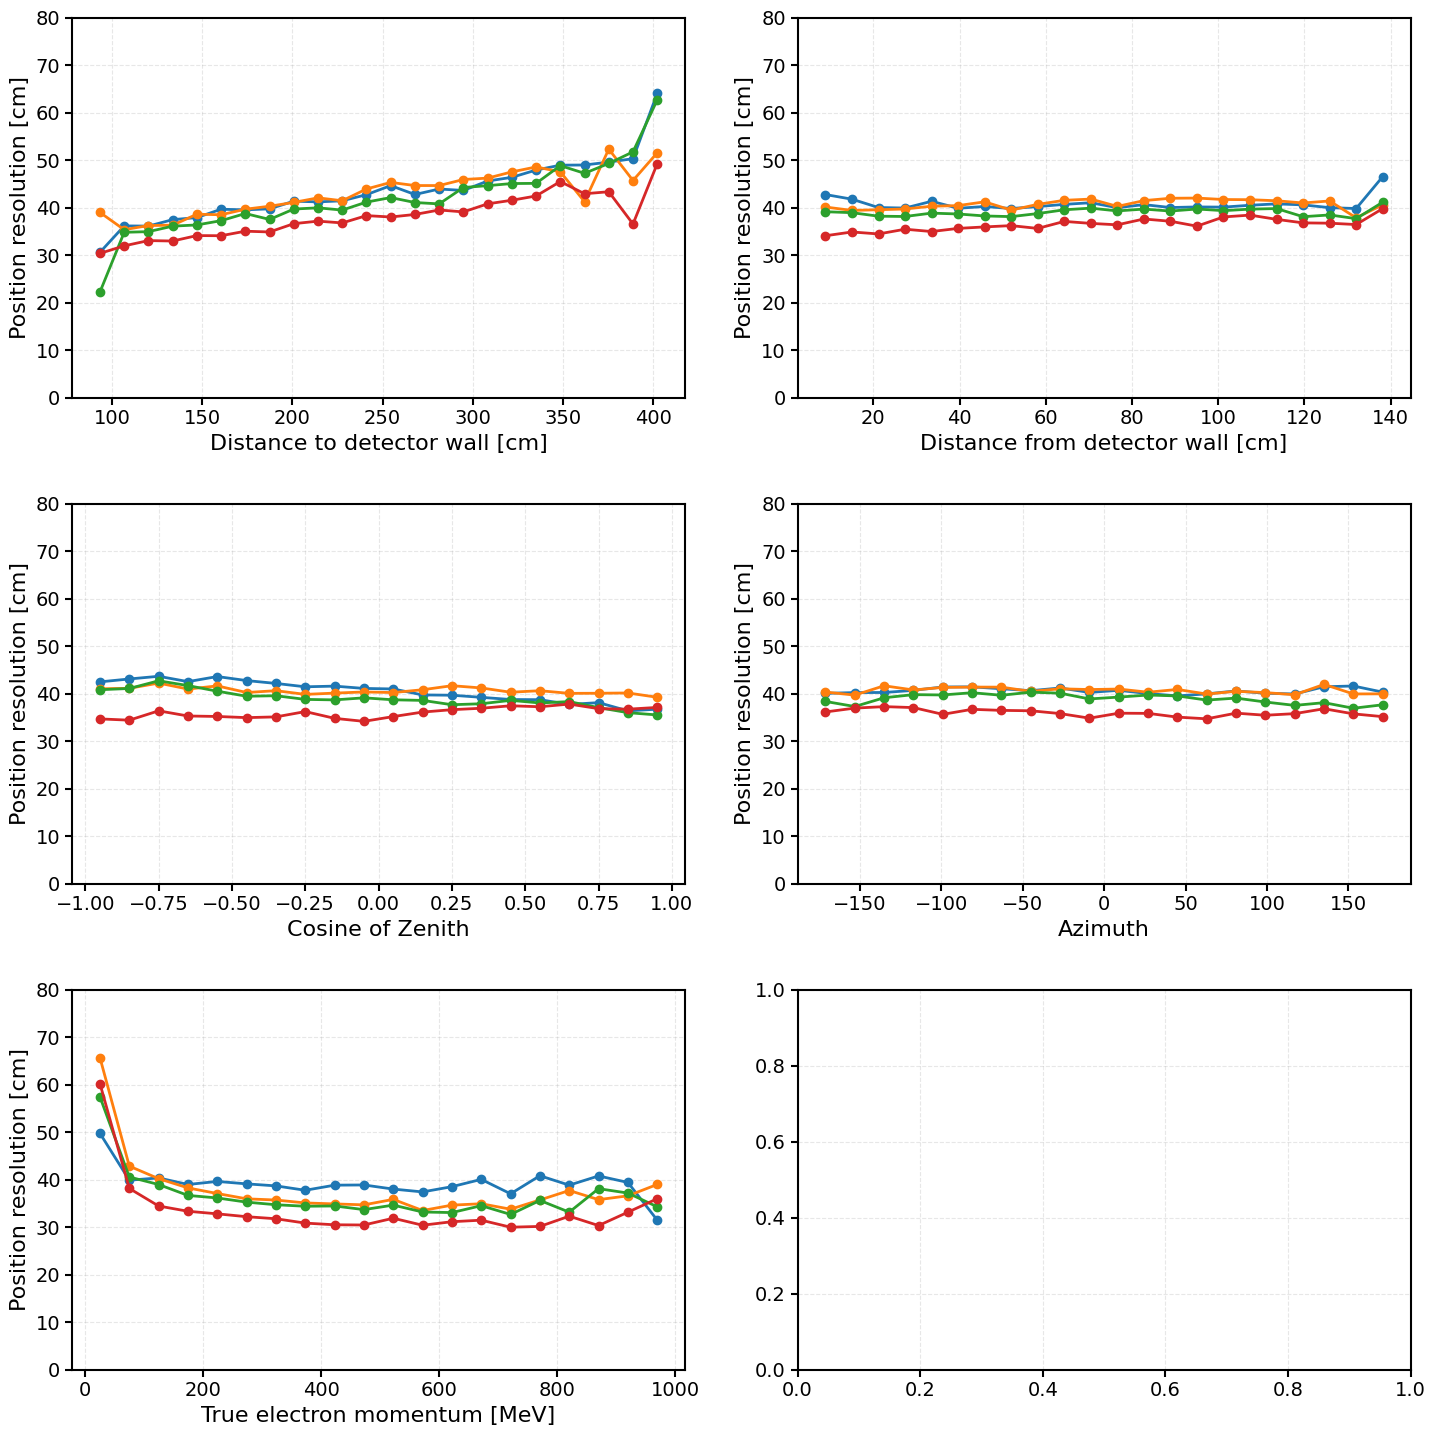

In [60]:
# can add y_lim for the y axis


all_runs_pos = e_position_truth_0 ## must use truth for truth binning

figs, axes = plt.subplots(3,2, figsize=(15, 15))
for r in all_runs_pos:
    plot_resolution_profile([r], 'position_3d_errors', e_towall_binning_0, ax=axes[0,0],y_lim=(0,80), x_label="Distance to detector wall [cm]", y_label="Position resolution [cm]",legend=None)
    plot_resolution_profile([r], 'position_3d_errors',e_dwall_binning_0, ax=axes[0,1], y_lim=(0,80),x_label="Distance from detector wall [cm]",y_label="Position resolution [cm]",legend=None)
    plot_resolution_profile([r],'position_3d_errors', e_cos_zenith_binning_0, ax=axes[1,0], y_lim=(0,80),x_label="Cosine of Zenith", y_label="Position resolution [cm]", legend=None)
    plot_resolution_profile([r],'position_3d_errors', e_azimuth_binning_0,ax=axes[1,1],y_lim=(0,80),x_label="Azimuth",y_label="Position resolution [cm]",legend=None)
    plot_resolution_profile([r],'position_3d_errors',e_mom_binning_0, ax=axes[2,0],y_lim=(0,80),x_label="True electron momentum [MeV]",y_label="Position resolution [cm]",legend=None)

In [ ]:
all_runs_mom =  resnet_e_energy #+ [fitqun_e]

figs, axes = plt.subplots(3,2, figsize=(15, 15))
for r in all_runs_mom:
    plot_resolution_profile([r], 'momentum_residuals', e_towall_binning, ax=axes[0,0], y_lim = (10,30), x_label="Distance to detector wall [cm]", y_label="Energy resolution",legend=None)
    plot_resolution_profile([r], 'momentum_residuals', e_dwall_binning, ax=axes[0,1],  y_lim = (10,30),x_label="Distance from detector wall [cm]",y_label="Energy resolution",legend=None)
    plot_resolution_profile([r],'momentum_residuals', e_cos_zenith_binning, ax=axes[1,0],  y_lim = (10,30),x_label="Cosine of Zenith", y_label="Energy resolution", legend=None)
    plot_resolution_profile([r],'momentum_residuals',e_azimuth_binning,ax=axes[1,1], y_lim = (10,30),x_label="Azimuth",y_label="Energy resolution",legend=None)
    plot_resolution_profile([r],'momentum_residuals', e_mom_binning, ax=axes[2,0], y_lim = (10,30),x_label="True electron momentum [MeV]",y_label="Energy resolution",legend=None)

In [ ]:
all_runs_dir =  resnet_e_direction #+ [fitqun_e]

figs, axes = plt.subplots(3,2, figsize=(15, 15))
for r in all_runs_dir:
    plot_resolution_profile([r], 'direction_errors', e_towall_binning, ax=axes[0,0], y_lim =(3,15), x_label="Distance to detector wall [cm]", y_label="Direction resolution",legend=None)
    plot_resolution_profile([r], 'direction_errors', e_dwall_binning, ax=axes[0,1],  y_lim =(3,15),x_label="Distance from detector wall [cm]",y_label="Direction resolution",legend=None)
    plot_resolution_profile([r],'direction_errors', e_cos_zenith_binning, ax=axes[1,0],  y_lim =(3,15),x_label="Cosine of Zenith", y_label="Direction resolution", legend=None)
    plot_resolution_profile([r],'direction_errors',e_azimuth_binning,ax=axes[1,1], y_lim =(3,15),x_label="Azimuth",y_label="Direction Momentum",legend=None)
    plot_resolution_profile([r],'direction_errors', e_mom_binning, ax=axes[2,0], y_lim =(3,15),x_label="True electron momentum [MeV]",y_label="Direction resolution",legend=None)

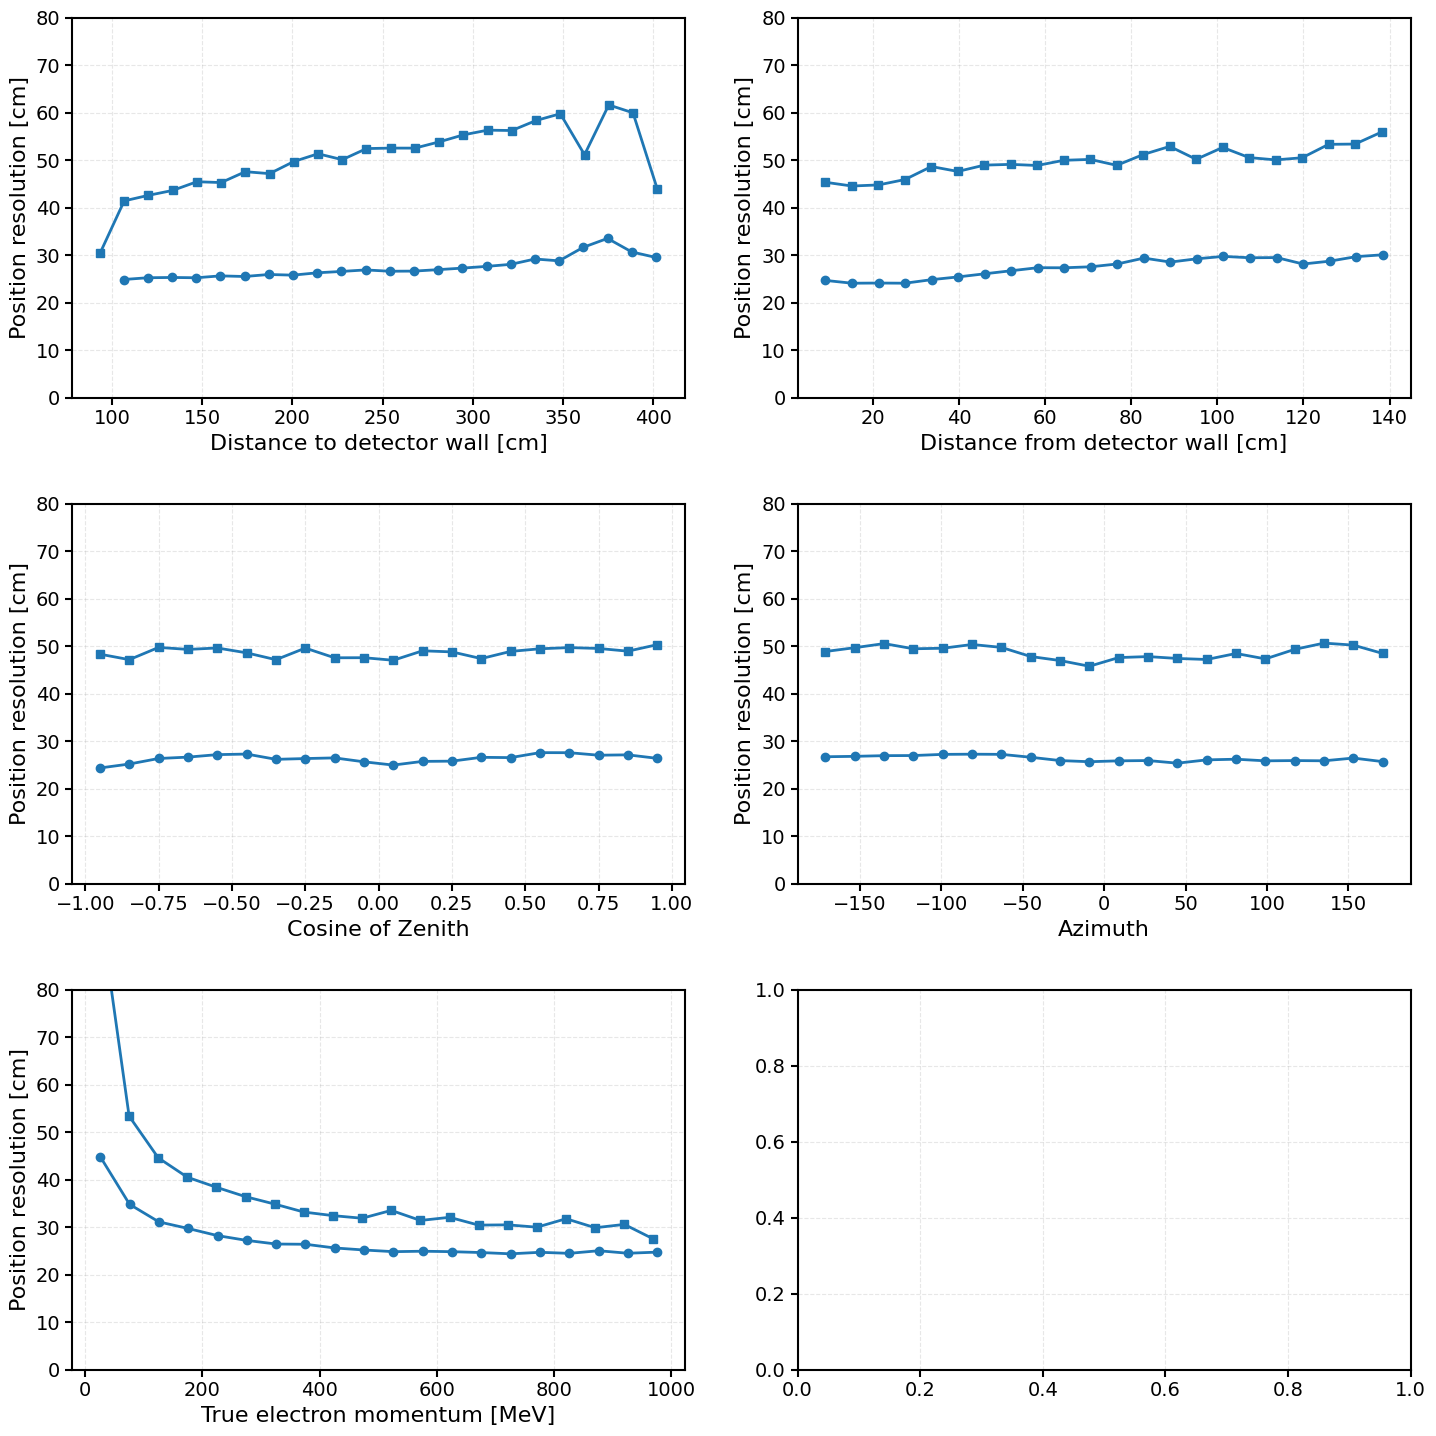

In [76]:
### 2 particle plots

# all_runs_pos = e_position_slot_0 + e_position_slot_1

n_colours = len(e_position_truth_0)
colours = plt.cm.tab10(np.linspace(0, 1, n_colours))

figs, axes = plt.subplots(3,2, figsize=(15, 15))
for n, r in enumerate(e_position_truth_0):
    plot_resolution_profile([r], 'position_3d_errors', e_towall_binning_0, ax=axes[0,0],y_lim=(0,80), x_label="Distance to detector wall [cm]", y_label="Position resolution [cm]",legend=None, marker='s', color = colours[n])
    plot_resolution_profile([r], 'position_3d_errors',e_dwall_binning_0, ax=axes[0,1], y_lim=(0,80),x_label="Distance from detector wall [cm]",y_label="Position resolution [cm]",legend=None, marker='s', color = colours[n])
    plot_resolution_profile([r],'position_3d_errors', e_cos_zenith_binning_0, ax=axes[1,0], y_lim=(0,80),x_label="Cosine of Zenith", y_label="Position resolution [cm]", legend=None, marker='s', color = colours[n])
    plot_resolution_profile([r],'position_3d_errors', e_azimuth_binning_0,ax=axes[1,1],y_lim=(0,80),x_label="Azimuth",y_label="Position resolution [cm]",legend=None, marker='s', color = colours[n])
    plot_resolution_profile([r],'position_3d_errors',e_mom_binning_0, ax=axes[2,0],y_lim=(0,80),x_label="True electron momentum [MeV]",y_label="Position resolution [cm]",legend=None, marker='s', color = colours[n])
for n, r in enumerate(e_position_truth_1):
    plot_resolution_profile([r], 'position_3d_errors', e_towall_binning_1, ax=axes[0,0],y_lim=(0,80), x_label="Distance to detector wall [cm]", y_label="Position resolution [cm]",legend=None, color = colours[n])
    plot_resolution_profile([r], 'position_3d_errors',e_dwall_binning_1, ax=axes[0,1], y_lim=(0,80),x_label="Distance from detector wall [cm]",y_label="Position resolution [cm]",legend=None, color = colours[n])
    plot_resolution_profile([r],'position_3d_errors', e_cos_zenith_binning_1, ax=axes[1,0], y_lim=(0,80),x_label="Cosine of Zenith", y_label="Position resolution [cm]", legend=None, color = colours[n])
    plot_resolution_profile([r],'position_3d_errors', e_azimuth_binning_1,ax=axes[1,1],y_lim=(0,80),x_label="Azimuth",y_label="Position resolution [cm]",legend=None, color = colours[n])
    plot_resolution_profile([r],'position_3d_errors',e_mom_binning_1, ax=axes[2,0],y_lim=(0,80),x_label="True electron momentum [MeV]",y_label="Position resolution [cm]",legend=None, color = colours[n])


In [ ]:
# print(len(data_new_geo["positions"][h5_keep_idx][mu_mask_h5]))
# print(len(mu_pos[mu_cuts]))

# # A = test_idxs_new_geo[h5_keep_idx][mu_mask_h5]
# # B = test_idxs_new_geo[mu_idxs_new_geo][mu_cuts]

# # print(len(A), len(B))
# # print(np.array_equal(A, B))                 # identical set + order
# # print(np.array_equal(np.sort(A), np.sort(B)))  # identical set ignoring order


In [ ]:
from matplotlib.ticker import MaxNLocator, LogLocator
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({
    'axes.labelsize': 15,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
})

labels = np.asarray(data_new_geo["labels"][h5_keep_idx]).astype(int)
# mu_sel = cuts_new_geo[h5_keep_idx] & (labels == 2)
mu_mask_h5 = (labels == 2) & cuts_new_geo[h5_keep_idx] 


# instead of using the filtered muons list (from get quantities), im using all and then applying both the muon and the physical cuts as a selection filter (when binning) - therefore the baseline dimension is just the common events between h5 and fitqun

# resnet_muon_position = WatChMaLPositionRegression(
#     outdir_reg + output_pos,
#     "ResNet50 QT+mPMT_pos",
#     true_positions=data_new_geo["positions"][h5_keep_idx],
#     true_directions=data_new_geo["directions"][h5_keep_idx],
#     indices=test_idxs_new_geo[h5_keep_idx],
#     selection=mu_mask_h5
# )


resnet_muon_direction = WatChMaLPositionRegression(
    outdir_reg + output_dir,
    "ResNet50 QT+mPMT_pos",
    true_positions=data_new_geo["positions"][h5_keep_idx],
    true_directions=data_new_geo["directions"][h5_keep_idx],
    indices=test_idxs_new_geo[h5_keep_idx],
    selection=mu_mask_h5
)

# fitqun_mu = FitQun1ParticleFit(
#     fq,
#     "fiTQun",
#     true_positions=data_new_geo["positions"][h5_keep_idx][mu_mask_h5],
#     true_directions=data_new_geo["directions"][h5_keep_idx][mu_mask_h5],
#     true_momenta=data_new_geo["momentum"][h5_keep_idx][mu_mask_h5],
#     true_labels=2,                        
#     indices=fq_keep_idx[mu_mask_h5],       
#     selection=None,
# )


muon_mom_binning = [
    get_binning(data_new_geo["momentum"][h5_keep_idx], 20, 0, 1000),
    get_binning(data_new_geo["momentum"][h5_keep_idx][mu_mask_h5], 20, 0, 1000),
]

muon_cos_zenith_binning = [
    get_binning(np.cos(data_new_geo["angles"][h5_keep_idx, 0]), 20, -1, 1),
    get_binning(np.cos(data_new_geo["angles"][h5_keep_idx, 0][mu_mask_h5]), 20, -1, 1),
]

muon_azimuth_binning = [
    get_binning(data_new_geo["angles"][h5_keep_idx, 1] * 180 / np.pi, 20, -180, 180),
    get_binning(data_new_geo["angles"][h5_keep_idx, 1][mu_mask_h5] * 180 / np.pi, 20, -180, 180),
]

muon_dwall_binning = [
    get_binning(data_new_geo["dwall"][h5_keep_idx], 22, 50, 300),
    get_binning(data_new_geo["dwall"][h5_keep_idx][mu_mask_h5], 22, 50, 300),
]

muon_towall_binning = [
    get_binning(data_new_geo["towall"][h5_keep_idx], 30, 50, 800),
    get_binning(data_new_geo["towall"][h5_keep_idx][mu_mask_h5], 30, 50, 800),
]
all_runs_pos = [resnet_muon_direction, fitqun_mu]

for r in all_runs_dir:
    plot_resolution_profile([r], 'direction_errors', e_towall_binning, ax=axes[0,0], x_label="Distance to detector wall [cm]", y_label="Direction resolution",legend=None)
    plot_resolution_profile([r], 'direction_errors', e_dwall_binning, ax=axes[0,1], x_label="Distance from detector wall [cm]",y_label="Direction resolution",legend=None)
    plot_resolution_profile([r],'direction_errors', e_cos_zenith_binning, ax=axes[1,0], x_label="Cosine of Zenith", y_label="Direction resolution", legend=None)
    plot_resolution_profile([r],'direction_errors',e_azimuth_binning,ax=axes[1,1],x_label="Azimuth",y_label="Direction Momentum",legend=None)
    plot_resolution_profile([r],'direction_errors', e_mom_binning, ax=axes[2,0],x_label="True electron momentum [MeV]",y_label="Direction resolution",legend=None)


# fig1, ax1 = plt.subplots(figsize=(10, 7))

# for r in range(len(all_runs_pos)):
#     plot_resolution_profile(
#         [all_runs_pos[r]],
#         'position_3d_errors',
#         muon_towall_binning[r],       
#         ax=ax1,
#         x_label="Distance to detector wall [cm]",
#         y_label="Position resolution [cm]",
#         legend=None
#     )

# ax1.set_title("Muon 3D Position Resolution vs Distance to Wall", fontsize=16)
# fig1.tight_layout()

# handles, labels = ax1.get_legend_handles_labels()


# fig2, ax2 = plt.subplots(figsize=(10, 7))

# for r in range(len(all_runs_pos)):
#     plot_resolution_profile(
#         [all_runs_pos[r]],
#         'position_3d_errors',
#         muon_dwall_binning[r],
#         ax=ax2,
#         x_label="Distance from detector wall [cm]",
#         y_label="Position resolution [cm]",
#         legend=None
#     )

# ax2.set_title("Muon 3D Position Resolution vs Distance from Wall", fontsize=16)
# fig2.tight_layout()

# handles, labels = ax2.get_legend_handles_labels()

# fig3, ax3 = plt.subplots(figsize=(10, 7))

# for r in range(len(all_runs_pos)):
#     plot_resolution_profile(
#         [all_runs_pos[r]],
#         'position_3d_errors',
#         muon_cos_zenith_binning[r],
#         ax=ax3,
#         x_label="Cosine of Zenith",
#         y_label="Position resolution [cm]",
#         legend=None
#     )

# ax3.set_title("Muon 3D Position Resolution vs Cosine of Zenith", fontsize=16)
# fig3.tight_layout()

# handles, labels = ax3.get_legend_handles_labels()


# fig4, ax4 = plt.subplots(figsize=(10, 7))

# for r in range(len(all_runs_pos)):
#     plot_resolution_profile(
#         [all_runs_pos[r]],
#         'position_3d_errors',
#         muon_azimuth_binning[r],
#         ax=ax4,
#         x_label="Azimuth [°]",
#         y_label="Position resolution [cm]",
#         legend=None
#     )

# ax4.set_title("Muon 3D Position Resolution vs Azimuth", fontsize=16)
# fig4.tight_layout()

# handles, labels = ax4.get_legend_handles_labels()


# fig5, ax5 = plt.subplots(figsize=(10, 7))

# for r in range(len(all_runs_pos)):
#     plot_resolution_profile(
#         [all_runs_pos[r]],
#         'position_3d_errors',
#         muon_mom_binning[r],
#         ax=ax5,
#         x_label="True muon momentum [MeV]",
#         y_label="Position resolution [cm]",
#         legend=None
#     )

# ax5.xaxis.set_major_locator(MaxNLocator(nbins=10))
# ax5.set_title("Muon 3D Position Resolution vs Momentum", fontsize=16)
# fig5.tight_layout()

# handles, labels = ax5.get_legend_handles_labels()

# fig_legend, ax_legend = plt.subplots(1, 1, figsize=(10, 2))
# ax_legend.axis('off')
# ax_legend.legend(handles, labels, loc='center', fontsize=14, ncol=len(labels))
# fig_legend.tight_layout()

# plt.show()


In [ ]:

# labels = np.asarray(data_new_geo["labels"][h5_keep_idx]).astype(int)
# # mu_sel = cuts_new_geo[h5_keep_idx] & (labels == 2)
# # mu_mask_h5 = (labels == 2) & cuts_new_geo[h5_keep_idx]

# resnet_muon_energy = WatChMaLEnergyRegression(
#     outdir_reg + output_energy,             
#     "ResNet50 QT+mPMT_E",
#     true_momenta=data_new_geo["momentum"][h5_keep_idx],   
#     true_labels=labels,                                  
#     indices=test_idxs_new_geo[h5_keep_idx],
#     selection=mu_mask_h5
# )

# # fitqun_mu = FitQun1ParticleFit(
# #     fq,
# #     "fiTQun",
# #     true_positions=data_new_geo["positions"][h5_keep_idx][mu_mask_h5],
# #     true_directions=data_new_geo["directions"][h5_keep_idx][mu_mask_h5],
# #     true_momenta=data_new_geo["momentum"][h5_keep_idx][mu_mask_h5],
# #     true_labels=2,
# #     indices=fq_keep_idx[mu_mask_h5],
# #     selection=None,
# # )

# all_runs_pos = [resnet_muon_energy, fitqun_mu]

# fig1, ax1 = plt.subplots(figsize=(10, 7))
# for r in range(len(all_runs_pos)):
#     plot_resolution_profile(
#         [all_runs_pos[r]],
#         "energy_residuals",
#         muon_towall_binning[r],
#         ax=ax1,
#         x_label="Distance to detector wall [cm]",
#         y_label="Energy resolution [cm]",
#         legend=None
#     )
# ax1.set_title("Muon Energy Resolution vs Distance to Wall", fontsize=16)
# fig1.tight_layout()
# handles, labels = ax1.get_legend_handles_labels()

# fig2, ax2 = plt.subplots(figsize=(10, 7))
# for r in range(len(all_runs_pos)):
#     plot_resolution_profile(
#         [all_runs_pos[r]],
#         "energy_residuals",
#         muon_dwall_binning[r],
#         ax=ax2,
#         x_label="Distance from detector wall [cm]",
#         y_label="Energy resolution [cm]",
#         legend=None
#     )
# ax2.set_title("Muon Energy Resolution vs Distance from Wall", fontsize=16)
# fig2.tight_layout()
# handles, labels = ax2.get_legend_handles_labels()

# fig3, ax3 = plt.subplots(figsize=(10, 7))
# for r in range(len(all_runs_pos)):
#     plot_resolution_profile(
#         [all_runs_pos[r]],
#         "energy_residuals",
#         muon_cos_zenith_binning[r],
#         ax=ax3,
#         x_label="Cosine of Zenith",
#         y_label="Energy resolution [cm]",
#         legend=None
#     )
# ax3.set_title("Muon Energy Resolution vs Cosine of Zenith", fontsize=16)
# fig3.tight_layout()
# handles, labels = ax3.get_legend_handles_labels()

# fig4, ax4 = plt.subplots(figsize=(10, 7))
# for r in range(len(all_runs_pos)):
#     plot_resolution_profile(
#         [all_runs_pos[r]],
#         "energy_residuals",
#         muon_azimuth_binning[r],
#         ax=ax4,
#         x_label="Azimuth [°]",
#         y_label="Energy resolution [cm]",
#         legend=None
#     )
# ax4.set_title("Muon Energy Resolution vs Azimuth", fontsize=16)
# fig4.tight_layout()
# handles, labels = ax4.get_legend_handles_labels()

# fig5, ax5 = plt.subplots(figsize=(10, 7))
# for r in range(len(all_runs_pos)):
#     plot_resolution_profile(
#         [all_runs_pos[r]],
#         "energy_residuals",
#         muon_mom_binning[r],
#         ax=ax5,
#         x_label="True muon energy [MeV]",
#         y_label="Energy resolution [cm]",
#         legend=None
#     )
# ax5.xaxis.set_major_locator(MaxNLocator(nbins=10))
# ax5.set_title("Muon Energy Resolution vs Energy", fontsize=16)
# fig5.tight_layout()
# handles, labels = ax5.get_legend_handles_labels()

# fig_legend, ax_legend = plt.subplots(1, 1, figsize=(10, 2))
# ax_legend.axis('off')
# ax_legend.legend(handles, labels, loc='center', fontsize=14, ncol=len(labels))
# fig_legend.tight_layout()

# plt.show()

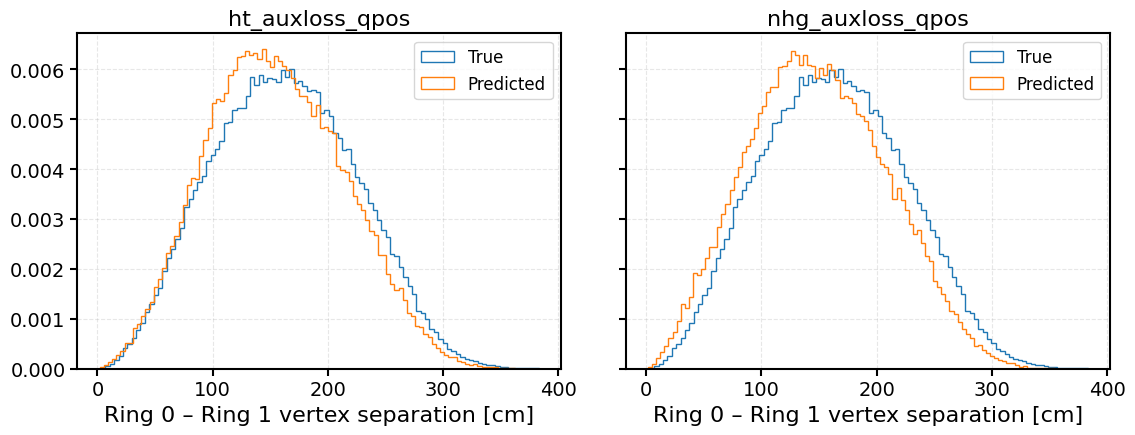

In [70]:
import numpy as np
import matplotlib.pyplot as plt

# ---- runs ----
separation_runs = [WatChMaLPositionRegression(outdir_reg + ht_auxloss_qpos, None, "ht_auxloss_qpos", e_pos, e_dir, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
WatChMaLPositionRegression(outdir_reg + nhg_auxloss_qpos, None, "nhg_auxloss_qpos", e_pos, e_dir, **electron_args_new_geo_1, match_truth=data_new_geo['positions'], **resnet_args),
]

# ---- separation computation ----
def ring_separation(run, true_positions_full):
    """Return (pred_sep, true_sep) in cm, selection-applied."""
    run.ring = 0
    p0 = run.get_outputs("predicted_positions", select_ring=True, concatenate= False)
    run.ring = 1
    p1 = run.get_outputs("predicted_positions", select_ring=True, concatenate= False)

    pred_sep = np.linalg.norm(p0 - p1, axis=1)
    true_sep = np.linalg.norm(true_positions_full[:, 0] - true_positions_full[:, 1], axis=1)
    return pred_sep[run.selection], true_sep[run.selection]


In [ ]:
opening_angle = np.degrees(np.arccos(
    np.clip(np.sum(dir_0 * dir_1, axis=1), -1, 1)
))

def opening_angle(run, true_directions):
    dir_0_true = 
    dir_1_true = 
    
    run.ring = 0 
    dir_0_pred = run.get_outputs("predicted_directions", select_ring=True, concatenate=False)
    dir_1_pred = 
    
    opening_angle_true = np.degrees(np.arccos(
        np.clip(np.sum(dir_0_true * dir_1_true, axis=1), -1, 1)
    ))
    
    opening_angle_pred = np.degrees(np.arccos(
        np.clip(np.sum(dir_0_pred * dir_1_pred, axis=1), -1, 1)
    ))
    

In [ ]:
# ---- plots ----
fig, axes = plt.subplots(1, len(separation_runs), figsize=(12, 5), sharex=True, sharey=True)
for ax, run in zip(axes, separation_runs):
    pred_sep, true_sep = ring_separation(run, data_new_geo['positions'])
    ax.hist(true_sep, bins=100, histtype='step', label='True', density=True)
    ax.hist(pred_sep, bins=100, histtype='step', label='Predicted', density=True)
    res = np.quantile(np.abs(pred_sep - true_sep), 0.68)
    ax.set_title(f"{run.run_label}")
    ax.set_xlabel("Ring 0 – Ring 1 vertex separation [cm]")
    ax.legend()
plt.tight_layout()